# CSoT'26 - ML in Astronomy - Week 2 . Part 1: Baseline with Scikit-Learn (Starter)

**Goal:** Flatten the galaxy images into NumPy feature rows, train simple scikit-learn classifiers (KNN, Logistic Regression), and record the **baseline accuracy** that every later model must beat.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). The GPU isn't strictly needed for sklearn, but we reuse the Week 1 GPU pipeline.
2. Read [`01-tensors-to-numpy-and-flattening.md`](../01-tensors-to-numpy-and-flattening.md) and [`02-baseline-with-scikit-learn.md`](../02-baseline-with-scikit-learn.md).

Each `TODO` cell has a short instruction. Replace the placeholder with working code, then run the cell. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 — Re-create the Week 1 data pipeline

Week 2 builds directly on the `DataLoader`s from Week 1. The cells below reproduce that pipeline (download is commented out — uncomment it the first time, exactly as in [`week1_data_solution.ipynb`](../../Week-1/notebooks/week1_data_solution.ipynb)). If you saved `galaxy_data/` to Google Drive in Week 1, just re-mount Drive and point `DATA_ROOT` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [6]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2/images"   # adjust if your JPGs landed one folder deeper
DATA_ROOT = Path("galaxy_data")        # we create train/val/test subfolders here
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

# --- Download via Kaggle API (run once) ---
# from google.colab import files
# files.upload()  # select kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !pip -q install kaggle pandas
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# !unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}
# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}
# !wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
# !gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)

# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

print("\nMapping CSV preview:")
print(pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3))

print("\nLabels CSV preview (note dr7objid — we rename to objid before merging):")
print(pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3)[["dr7objid", "gz2_class"]])

def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, …) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None  # artifact / ambiguous
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    """Join Kaggle mapping (objid ↔ asset_id) with Hart et al. morphology labels."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    return df


def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True
def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}//*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nExample rows:")
print(df[["asset_id", "objid", "gz2_class", "label"]].head())
PER_CLASS = 200  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}  n={len(ds):4d}  classes={ds.classes}")

print("class_to_idx:", train_ds.class_to_idx)
image, label = train_ds[0]
print("shape :", image.shape)
print("dtype :", image.dtype)
print("label :", label, "->", train_ds.classes[label])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("train batch images:", images.shape)   # (32, 3, 64, 64)
print("train batch labels:", labels.shape)     # (32,)


RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434

Mapping CSV preview:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3

Labels CSV preview (note dr7objid — we rename to objid before merging):
             dr7objid gz2_class
0  587732591714893851      Sc+t
1  588009368545984617      Sb+t
2  587732484359913515        Ei
Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64

Example rows:
   asset_id               objid gz2_class       label
0         3  587722981741363294        Sb      spiral
1         4  587722981741363323      Sc?l      spiral
2         5  587722981741559888        Er  elliptical
3         6  58

## Step 1 - From DataLoader to NumPy feature matrices

scikit-learn wants a 2D array `X` of shape `(n_samples, n_features)` and a 1D array `y` of labels. We get there by iterating the loader, flattening each batch with `flatten(start_dim=1)` (keeping the batch dim), and concatenating.

In [7]:
# TODO: write loader_to_numpy(loader) that returns (X, y) as NumPy arrays.
#   - for each (images, labels) batch: flat = images.flatten(start_dim=1)
def loader_to_numpy(loader):
    Xs = []
    ys = []

    for images, labels in loader:
        Xs.append(images.flatten(start_dim=1).numpy())
        ys.append(labels.numpy())

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)

    return X, y

X_train, y_train = loader_to_numpy(train_loader)
X_test, y_test = loader_to_numpy(test_loader)

print(X_train.shape)
print(X_test.shape)
#   - collect flat.numpy() and labels.numpy(), then np.concatenate along axis 0
# Then build X_train, y_train from train_loader and X_test, y_test from test_loader.
# Print X_train.shape and X_test.shape (expect (N, 12288)).

(420, 12288)
(90, 12288)


## Step 2 - The 'do-nothing' floors

Before any real model: the majority-class baseline. A model that always predicts the most common class already scores this much - so this, not random chance, is the number to beat.

In [17]:
# TODO: fit a DummyClassifier(strategy="most_frequent") on (X_train, y_train)
from sklearn.dummy import DummyClassifier # importing classifier
clf = DummyClassifier(strategy="most_frequent") # creating a dummy most frequent model
clf.fit(X_train, y_train) # fitting the data in the model
dummy_acc = clf.score(X_test, y_test) #testing the accuracy of dummy model on the test dataset
predictions = clf.predict(X_test)
print("Dummy accuracy:", dummy_acc)
print(predictions) # as we can see its just outputting the most frequent as its solution
#       and print its accuracy on (X_test, y_test). Also print 1/num_classes (random).

Dummy accuracy: 0.3333333333333333
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Step 3 - K-Nearest Neighbours

KNN classifies a galaxy by majority vote of its `k` closest training galaxies in 12 288-D pixel space. There is no real 'training' - it just memorises the data.

In [18]:
# TODO: fit KNeighborsClassifier(n_neighbors=5) on the train set and print its TEST accuracy.
from sklearn.neighbors import KNeighborsClassifier #import KNN classifier
knn = KNeighborsClassifier(n_neighbors=5) #create the knn model
knn.fit(X_train, y_train) #fitting the knn model to the training data
knn_acc = knn.score(X_test, y_test) # gets the accuracy of the knn model
print("KNN accuracy:", knn_acc) #prints accuracy
predictions = knn.predict(X_test)
print(predictions) # prints the predictions of knn model

KNN accuracy: 0.4111111111111111
[0 0 1 0 0 0 0 0 0 0 1 0 0 1 2 0 0 0 2 0 0 1 2 1 0 0 1 0 1 2 2 1 2 0 1 0 0
 1 1 2 1 2 1 0 1 0 0 1 2 1 0 1 1 0 0 1 0 1 2 1 0 0 1 0 0 1 1 0 1 1 0 2 1 2
 1 0 1 0 0 1 0 1 0 1 1 2 1 1 2 0]


## Step 4 - Logistic Regression

A linear classifier: a weighted sum of the 12 288 pixel features per class, squashed by a softmax. Effectively a single-layer neural network. `max_iter` is raised because high-dimensional data is slow to converge.

In [19]:
# TODO: fit LogisticRegression(max_iter=1000) on the train set and print its TEST accuracy.
from sklearn.linear_model import LogisticRegression # importing logistic regression model
logreg = LogisticRegression(
    max_iter = 1000,
)
logreg.fit(X_train, y_train) # fitting the data in the model
#created the logreg model
logreg_acc = logreg.score(X_test, y_test) # score of the lgr model on the training dataset
print("logreg accuracy", logreg_acc)
print(logreg.predict(X_test))


logreg accuracy 0.4666666666666667
[0 2 1 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 2 1 2 1 1 0 1 0 1 0 2 0 2 2 1 2 1 1 1
 2 1 2 1 1 0 2 1 2 2 1 1 1 0 2 0 2 2 1 2 2 1 2 1 1 1 2 1 2 2 2 0 1 1 1 1 2
 1 0 2 0 2 1 1 1 2 2 1 1 1 2 2 1]


## Step 5 - The comparison table (the bar to beat)

Put the numbers side by side. The best of these is the baseline your Week 3 CNN must clearly beat.

In [20]:
# TODO: print a small table comparing: random (1/num_classes), majority, KNN, LogReg.
#       Identify (in a print statement) the single number Week 3 must beat.
print("Model\t\tAccuracy")
num_classes = 3
print("-" * 30)
print("Random\t\t", 1/num_classes)
print("Majority\t", dummy_acc)
print("KNN\t\t", knn_acc)
print("LogReg\t\t", logreg_acc)

print("\nWeek 3 CNN must beat:", max(dummy_acc, knn_acc, logreg_acc))

Model		Accuracy
------------------------------
Random		 0.3333333333333333
Majority	 0.3333333333333333
KNN		 0.4111111111111111
LogReg		 0.4666666666666667

Week 3 CNN must beat: 0.4666666666666667


## Step 6 (stretch) - Confusion matrix

Accuracy hides *which* classes get confused. Plot a confusion matrix for the logistic-regression predictions and note the most-confused pair - we'll compare it to the CNN's matrix in Week 3.

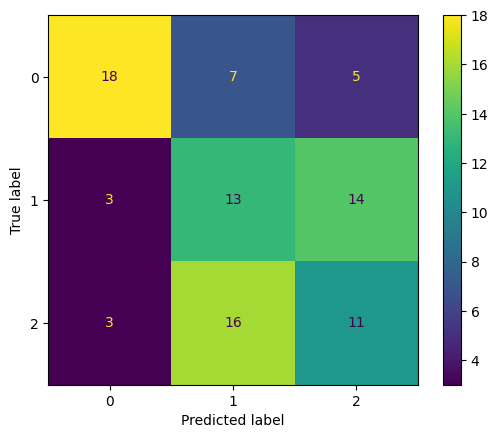

In [22]:
# TODO (optional): plot a confusion matrix for KNN or LogReg predictions.
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred) #good display of confusion matrix:)))


## Reflection

### 1. What baseline accuracy did you reach, and how far above the majority-class floor is it?

Logistic Regression achieved about 46.7% accuracy, which was noticeably higher than the majority-class baseline.

### 2. Why does flattening hurt a galaxy classifier specifically?

Flattening removes the spatial structure of the image, making features like spiral arms and galaxy shapes harder to recognize.

### 3. Which two classes do you expect a CNN to still find hardest to separate, and why?

I expect spiral and spiral_barred galaxies to be the hardest to separate because they look very similar and the bar feature can be subtle.